<a href="https://colab.research.google.com/github/Rijwan94/DS_Pyhton_M2/blob/main/Applied_Statistics_Project_PBA_Rijwan_Shaikh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Behavior Analysis using Descriptive Statistics

- Rijwan Shaikh

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset



Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





#Load Dataset

###Required Libraries

In [34]:
#Import Libraries
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from scipy.stats import binom, norm
from scipy.stats import poisson
from scipy.stats import expon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis, shapiro

Connect Drive

In [35]:
#Connect drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load CSV File / Dataset

In [36]:
#Load CSV File
PBA_df = pd.read_csv('/content/drive/MyDrive/Data Science/5. Applied Statistics/Mid Course/Superstore Marketing Data - Sheet1.csv', encoding='latin-1')


In [37]:
# Dataframe View
PBA_df

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,########,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,########,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [38]:
# Assuming PBA_df is already loaded
current_year = datetime.now().year

# Create Age column
PBA_df["Age"] = current_year - PBA_df["Year_Birth"]

# Display the updated DataFrame
PBA_df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,189,218,1,4,4,6,1,1,0,55
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,0,37,1,7,3,7,5,1,0,64
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,2,30,1,3,2,5,2,0,0,67
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,1,1,0,2,7,0,0,58
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,0,34,2,3,1,2,7,1,0,36


In [39]:
# Dataset Rows & Columns count
PBA_df.shape

(2240, 23)

In [40]:
# Dataset Info
PBA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**



**Deliverables**:

- **Cleaned and Preprocessed Dataset**:

  Provide a detailed report on the steps taken to handle missing values, including imputation methods used if applicable.
  Document the process of ensuring consistent data types for each variable, addressing any inconsistencies.

- **Summary of Basic Statistics**:

  Present calculated statistics such as mean, median, variance, and standard deviation for each relevant numerical variable.
  Include a concise table or summary showcasing these measures for easy reference.

In [41]:
# Check missing values
missing_values = PBA_df.isnull().sum()
missing_values


,0
Id,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


###**Note:**
**As Income column holding some missing rows which is around 1 % of full data count, we have to check which method is suitable for filling the missing rows.**

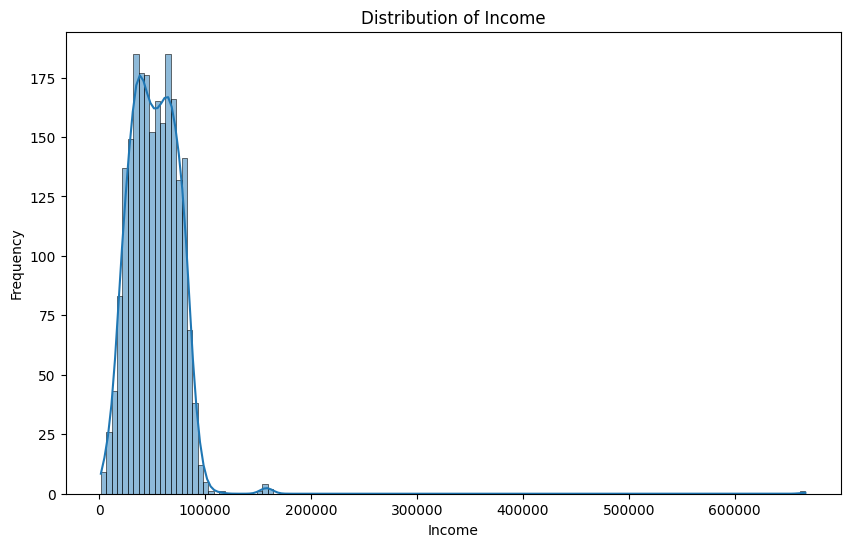

Mean Income: 52247.25135379061
Median Income: 51381.5
Mode Income: 7500.0
Skewness of Income: nan
Kurtosis of Income: nan
Income distribution is skewed. Median imputation is generally preferred.


In [42]:
#Find out which method is correct for filling the income column: mean or median.
income_mean = PBA_df['Income'].mean() #Calculate mean and assign to variable
income_median = PBA_df['Income'].median() #Calculate median and assign to variable
income_mode = PBA_df['Income'].mode()[0] #Calculate mode and assign to variable

# Analyze the distribution of the 'Income' column
plt.figure(figsize=(10, 6))
sns.histplot(PBA_df['Income'], kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

# Calculate skewness and kurtosis
income_skewness = skew(PBA_df['Income'])
income_kurtosis = kurtosis(PBA_df['Income'])

print(f"Mean Income: {income_mean}")
print(f"Median Income: {income_median}")
print(f"Mode Income: {income_mode}")
print(f"Skewness of Income: {income_skewness}")
print(f"Kurtosis of Income: {income_kurtosis}")


# Determine the best imputation method based on the distribution and skewness/kurtosis
# If the distribution is roughly symmetric and skewness is close to zero, mean imputation may be appropriate.
# If the distribution is skewed, median imputation is generally preferred as it is less sensitive to outliers.
# Mode imputation might be considered if the data is categorical or highly discrete.

# Example:
if abs(income_skewness) < 0.5:  # Adjust threshold as needed
    print("Income distribution is relatively symmetric. Mean imputation might be suitable.")
    # Impute with mean:
    # PBA_df['Income'].fillna(income_mean, inplace=True)
else:
    print("Income distribution is skewed. Median imputation is generally preferred.")
    # Impute with median:
    # PBA_df['Income'].fillna(income_median, inplace=True)


In [43]:
#Fill income with median
# Calculate the median income
income_median = PBA_df['Income'].median()
# Fill missing income values with the median
PBA_df['Income'].fillna(income_median, inplace=True)


<ipython-input-43-6c388c31afd1>:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [44]:
#null Value in Income
count = PBA_df['Income'].isnull().sum()
print('Income have', count ,'missing values after filling rows')

Income have 0 missing values after filling rows


In [45]:
# Age Distribution (Smaller Size)
fig_age = px.histogram(PBA_df, x="Age", marginal="box",
                       title="Distribution of Customer Age",
                       labels={"Age": "Age"},
                       opacity=0.7,
                       hover_data=["Age"])
fig_age.update_layout(bargap=0.1, width=500, height=300)  # Set smaller size
fig_age.show()

# Education Distribution (Smaller Size)
edu_counts = PBA_df["Education"].value_counts().reset_index()
edu_counts.columns = ["Education_Level", "Count"]
fig_edu = px.bar(edu_counts,
                 x="Education_Level",
                 y="Count",
                 title="Distribution of Customer Education",
                 labels={"Education_Level": "Education Level", "Count": "Count"},
                 hover_data=["Count"])
fig_edu.update_layout(width=500, height=300)  # Set smaller size
fig_edu.show()

# Marital Status Distribution (Smaller Size)
marital_counts = PBA_df["Marital_Status"].value_counts().reset_index()
marital_counts.columns = ["Marital_Status", "Count"]
fig_marital = px.bar(marital_counts,
                      x="Marital_Status",
                      y="Count",
                      title="Distribution of Customer Marital Status",
                      labels={"Marital_Status": "Marital Status", "Count": "Count"},
                      hover_data=["Count"])
fig_marital.update_layout(width=500, height=300)  # Set smaller size
fig_marital.show()

# Descriptive Statistics for Age and Income
print(PBA_df[['Age', 'Income']].describe())

# Education percentage distribution
print(PBA_df['Education'].value_counts(normalize=True) * 100)

# Marital Status percentage distribution
print(PBA_df['Marital_Status'].value_counts(normalize=True) * 100)


               Age         Income
count  2240.000000    2240.000000
mean     56.194196   52237.975446
std      11.984069   25037.955891
min      29.000000    1730.000000
25%      48.000000   35538.750000
50%      55.000000   51381.500000
75%      66.000000   68289.750000
max     132.000000  666666.000000
Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: proportion, dtype: float64
Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
YOLO         0.089286
Absurd       0.089286
Name: proportion, dtype: float64


In [47]:
# Calculate descriptive statistics for numerical variables
numerical_vars = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
                  'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                  'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                  'NumWebVisitsMonth']

summary_stats = PBA_df[numerical_vars].describe()

# Add variance and standard deviation to the summary
summary_stats.loc['variance'] = PBA_df[numerical_vars].var()
summary_stats.loc['std_dev'] = PBA_df[numerical_vars].std()

# Display the summary statistics table
summary_stats


,Age,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2.240000e+03,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,56.194196,5.223798e+04,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,11.984069,2.503796e+04,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,29.000000,1.730000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,3.553875e+04,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,55.000000,5.138150e+04,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,66.000000,6.828975e+04,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,132.000000,6.666660e+05,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000
variance,143.617921,6.268992e+08,0.289873,0.296522,838.823673,113297.804709,1581.926033,50947.429388,2984.325391,1704.079555,2721.441683,3.733542,7.721252,8.544517,10.568729,5.888606
std_dev,11.984069,2.503796e+04,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645


##Task 2 - Descriptive Statistics 📊

- **Calculate measures of central tendency (mean, median, mode) and measures of dispersion (variance, standard deviation) for key variables. Identify and handle outliers if necessary.**


**Deliverables**:

- **Descriptive statistics that reveal the central tendencies, variations, and potential outliers in the dataset.**:

  

## Task 3 - Probability Distributions 🎲

- **Identify variables that could follow specific probability distributions (e.g., Binomial, Normal). Calculate probabilities and expected values based on these distributions.**



**Deliverables**:

- **Determination of suitable probability distributions for relevant variables and corresponding calculated probabilities and expected values.**:

  

## Task 4: Insights and Customer Segmentation 📈

- **Explore relationships between customer characteristics and spending habits. Segment customers based on their behaviors and characteristics.**

**Deliverables**:

- **Key insights regarding relationships between variables and distinct customer segments based on behaviors.**

  

## Task 5: Conclusion and Recommendations

- **Create clear visualizations to showcase your findings. Use insights to make recommendations for the company based on your analysis.**

**Deliverables**:

- **Well-designed visualizations that visually represent your insights and actionable recommendations based on customer behavior analysis.**

## Bonus Task - Geogebra Experiment



Here's the link to an intriguing GeoGebra experiment: [GeoGebra Experiment Link](https://www.geogebra.org/m/LZbwMZtJ)

This experiment lets you simulate coin flips as per your preferences and specifications!

Your task involves recording a video where you'll explain the concept of the **Law of Large Numbers** using this experiment. Dive further into the experience by adjusting the number of coins and exploring varying coin biases. 🪙📹🔍